This data set contains person-level data from a digitized image of a fine needle aspirate of a breast mass for people with suspected breast cancer. Researchers then measured 11 features of the image. The aim is to predict patient diagnosis. Features of the dataset are:

   -- -----------------------------------------
   1. Sample code number            id number
   2. Clump Thickness               1 - 10
   3. Uniformity of Cell Size       1 - 10
   4. Uniformity of Cell Shape      1 - 10
   5. Marginal Adhesion             1 - 10
   6. Single Epithelial Cell Size   1 - 10
   7. Bare Nuclei                   1 - 10
   8. Bland Chromatin               1 - 10
   9. Normal Nucleoli               1 - 10
  10. Mitoses                       1 - 10
  11. Class:                        (2 for benign, 4 for malignant)

More details of the dataset are available at: https://archive-beta.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+diagnostic


 Using a train/test split of 70/30, calculate the mean and standard deviation of each feature that will be used in the standard scalar?

What is the sensitivity and specificity of your classifiers?

For the logistic regression, vary the decision threshold to generate an ROC curve. 
- What is the sensitivity when the threshold is 0? 
- What is the sensitivity when the threshold is 1?
- If we want our classifier, a priori, to have a sensitivity of 95%, what is the corresponding sensitivity?

# Data Import 

The data for this exercise is imported below. 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from ydata_profiling import ProfileReport
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [2]:
data = pd.read_csv('/Users/judah/Machine learning and Advanced data methods/Lab Materials/Data Files/breast-cancer-wisconsin.csv', header = None, na_values='?')
data.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


In [3]:
# separate the features from the labels
y = data.iloc[:,10]
X = data.iloc[:,1:10]
X.head()

,1,2,3,4,5,6,7,8,9
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [4]:
data.info
data.head()
data[10].value_counts()
X.describe()

,1,2,3,4,5,6,7,8,9
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [5]:
# Handle missing data

data.isna().sum()

0      0
1      0
2      0
3      0
4      0
5      0
6     16
7      0
8      0
9      0
10     0
dtype: int64

In [ ]:
profile = ProfileReport(data, title = "Profile Reporting")

profile.to_notebook_iframe()

In [7]:
X[6] = X[6].fillna(X[6].mode()[0])

In [8]:
X.isna().sum()

1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

In [9]:
y_binary = (y == 4).astype(int)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42, stratify=y_binary)

In [11]:
pipeline = Pipeline([
    ('Scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [12]:
y_pred = pipeline.predict(X_test)

In [13]:
sm = confusion_matrix(y_test, y_pred)

print(sm)

[[133   5]
 [  4  68]]


In [14]:
%matplotlib inline

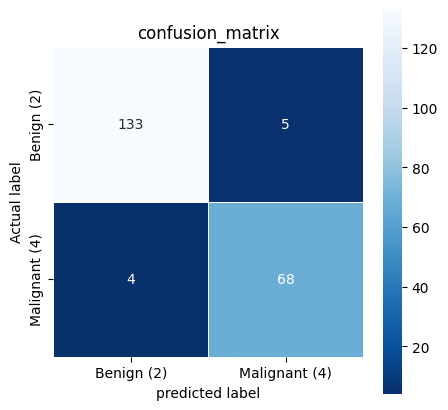

In [15]:

labels = ['Benign (2)' , 'Malignant (4)']

plt.figure(figsize=(5, 5))
sns.heatmap(sm, annot=True, fmt='d', linewidths=.5, square =True, cmap='Blues_r', xticklabels=labels, yticklabels=labels)

plt.ylabel('Actual label')
plt.xlabel('predicted label')
plt.title('confusion_matrix')
plt.show()

In [16]:
score = accuracy_score(y_test, y_pred)
print(score)

0.9571428571428572


In [17]:
classification = classification_report(y_test, y_pred)

print(classification)

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       138
           1       0.93      0.94      0.94        72

    accuracy                           0.96       210
   macro avg       0.95      0.95      0.95       210
weighted avg       0.96      0.96      0.96       210



In [18]:
tn, fp, fn, tp = sm.ravel()

In [19]:
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(sensitivity * 100)
print(specificity * 100)

94.44444444444444
96.37681159420289


In [20]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

In [22]:
auc_score

0.9925523349436393

In [23]:
print("=" * 65)
print("Q1: What is the sensitivity when the threshold is 0?")
print("-" * 65)
print("When threshold = 0, every sample is predicted as POSITIVE.")
print("All actual positives are correctly identified.")
print("→ Sensitivity (TPR) = 1.0  (100%)")
print("→ But Specificity = 0.0   (every benign case is misclassified)")
print()

Q1: What is the sensitivity when the threshold is 0?
-----------------------------------------------------------------
When threshold = 0, every sample is predicted as POSITIVE.
All actual positives are correctly identified.
→ Sensitivity (TPR) = 1.0  (100%)
→ But Specificity = 0.0   (every benign case is misclassified)



In [24]:
print("Q2: What is the sensitivity when the threshold is 1?")
print("-" * 65)
print("When threshold = 1, NO sample is predicted as positive.")
print("All actual positives are missed.")
print("→ Sensitivity (TPR) = 0.0  (0%)")
print("→ But Specificity = 1.0   (no false alarms)")
print()

Q2: What is the sensitivity when the threshold is 1?
-----------------------------------------------------------------
When threshold = 1, NO sample is predicted as positive.
All actual positives are missed.
→ Sensitivity (TPR) = 0.0  (0%)
→ But Specificity = 1.0   (no false alarms)



In [25]:
target_sensitivity = 0.95
idx = np.argmin(np.abs(tpr - target_sensitivity))
 
threshold_at_95 = thresholds[idx]
sensitivity_at_95 = tpr[idx]
specificity_at_95 = 1 - fpr[idx]

In [26]:
print("Q3: If we want sensitivity ≈ 95%, what is the specificity?")
print("-" * 65)
print(f"Closest threshold:   {threshold_at_95:.4f}")
print(f"Sensitivity (TPR):   {sensitivity_at_95:.4f}  ({sensitivity_at_95*100:.1f}%)")
print(f"Specificity (1-FPR): {specificity_at_95:.4f}  ({specificity_at_95*100:.1f}%)")
print(f"False Positive Rate: {fpr[idx]:.4f}  ({fpr[idx]*100:.1f}%)")
print("=" * 65)

Q3: If we want sensitivity ≈ 95%, what is the specificity?
-----------------------------------------------------------------
Closest threshold:   1.0000
Sensitivity (TPR):   0.9444  (94.4%)
Specificity (1-FPR): 0.9638  (96.4%)
False Positive Rate: 0.0362  (3.6%)


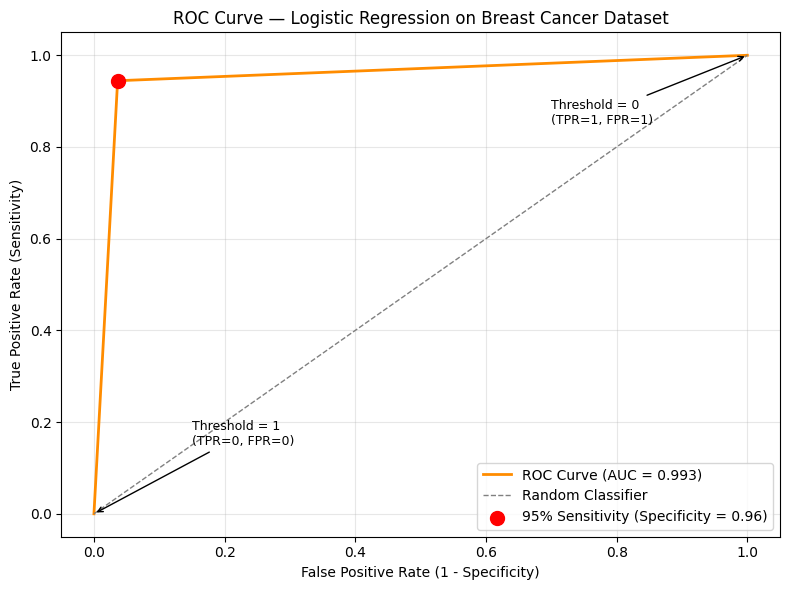


AUC Score: 0.993


In [27]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Classifier')
 
# Mark the 95% sensitivity point
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, zorder=5,
            label=f'95% Sensitivity (Specificity = {specificity_at_95:.2f})')
 
# Mark threshold = 0 corner (top-right: TPR=1, FPR=1)
plt.annotate('Threshold = 0\n(TPR=1, FPR=1)', xy=(1, 1), fontsize=9,
             xytext=(0.7, 0.85), arrowprops=dict(arrowstyle='->', color='black'))
 
# Mark threshold = 1 corner (bottom-left: TPR=0, FPR=0)
plt.annotate('Threshold = 1\n(TPR=0, FPR=0)', xy=(0, 0), fontsize=9,
             xytext=(0.15, 0.15), arrowprops=dict(arrowstyle='->', color='black'))
 
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Logistic Regression on Breast Cancer Dataset')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/judah/Machine learning and Advanced data methods/Lab Materials/roc_curve.png', dpi=150)
plt.show()
 
print(f"\nAUC Score: {auc_score:.3f}")
 